In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

TASK_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

from src.preprocessing import prepare_data, load_ground_truth, load_metadata
from src.solvers import RealNVP, AlphaDPISolver
from src.physics_model import SimpleCrescentNuisanceFloorParam2Img, NUFFTForwardModel
from src.visualization import (
    plot_corner, plot_elbo_comparison, plot_posterior_images,
    plot_loss_curves, compute_feature_metrics, print_feature_metrics,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
REF_DIR = os.path.join(TASK_ROOT, 'evaluation', 'reference_outputs')
print(f'Setup complete. Device: {device}')

Welcome to eht-imaging! v 1.2.4 

Setup complete. Device: cuda


In [2]:
(obs, obs_data, closure_indices, nufft_params,
 flux_const, metadata) = prepare_data(
    os.path.join(TASK_ROOT, 'data'))

npix = metadata['npix']
fov_uas = metadata['fov_uas']
pixel_size_uas = fov_uas / npix
extent_uas = fov_uas / 2

print(f'Image size       : {npix} x {npix}')
print(f'FOV              : {fov_uas} \u03bcas')
print(f'Pixel size       : {pixel_size_uas:.2f} \u03bcas/pixel')
print(f'Visibilities     : {len(obs_data["vis"])}')
print(f'Closure phases   : {len(closure_indices["cphase_data"]["cphase"])}')
print(f'Closure amps     : {len(closure_indices["camp_data"]["camp"])}')
print(f'Estimated flux   : {flux_const:.4f} Jy')

Loading uvfits:  /home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_feature_extraction/data/obs.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
U-V flagged 32/274 visibilities
U-V flagged 242/274 visibilities
Updated self.cphase: no averaging
updated self.cphase: avg_time 0.000000 s

updated self.camp: no averaging
updated self.camp: avg_time 0.000000 s

updated self.lcamp: no averaging
updated self.logcamp: avg_time 0.000000 s

Image size       : 64 x 64
FOV              : 120.0 μas
Pixel size       : 1.88 μas/pixel
Visibilities     : 274
Closure phases   : 141
Closure amps     : 149
Estimated flux   : 0.6007 Jy


Loading fits image:  /home/groot/Documents/PKUlab/imaging-101/tasks/eht_black_hole_feature_extraction/data/gt.fits


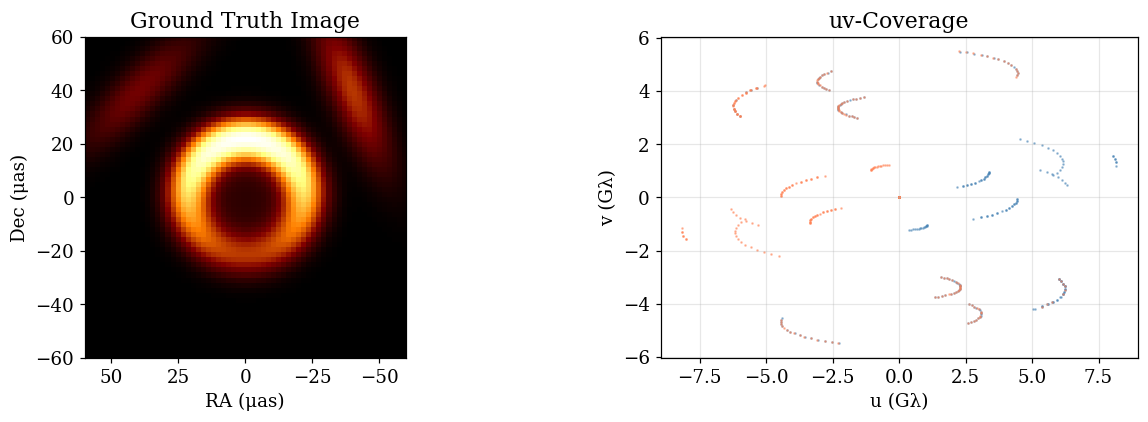

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Ground truth image
gt_image = load_ground_truth(os.path.join(TASK_ROOT, 'data'), npix, fov_uas)
extent = [extent_uas, -extent_uas, -extent_uas, extent_uas]
axes[0].imshow(gt_image, origin='lower', cmap='afmhot', extent=extent)
axes[0].set_xlabel('RA (\u03bcas)')
axes[0].set_ylabel('Dec (\u03bcas)')
axes[0].set_title('Ground Truth Image')

# uv-coverage
uv = obs_data['uv_coords'] / 1e9
axes[1].scatter(uv[:, 0], uv[:, 1], s=0.5, alpha=0.5, c='steelblue')
axes[1].scatter(-uv[:, 0], -uv[:, 1], s=0.5, alpha=0.5, c='coral')
axes[1].set_xlabel('u (G\u03bb)')
axes[1].set_ylabel('v (G\u03bb)')
axes[1].set_title('uv-Coverage')
axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
gt_params_dict = metadata.get('ground_truth_params', {})

print('Ground truth crescent parameters:')
print(f'  Diameter  : {gt_params_dict.get("diameter_uas", 44.0):.1f} \u03bcas')
print(f'  Width     : {gt_params_dict.get("width_uas", 11.36):.2f} \u03bcas')
print(f'  Asymmetry : {gt_params_dict.get("asymmetry", 0.5):.2f}')
print(f'  PA        : {gt_params_dict.get("position_angle_deg", -90.5):.1f} deg')
print(f'  N_gaussian: {gt_params_dict.get("n_gaussian", 2)}')

Ground truth crescent parameters:
  Diameter  : 44.0 μas
  Width     : 11.36 μas
  Asymmetry : 0.50
  PA        : -90.5 deg
  N_gaussian: 2


In [5]:
n_gaussian = metadata.get('n_gaussian', 2)

solver = AlphaDPISolver(
    npix=npix, fov_uas=fov_uas,
    n_flow=metadata['n_flow'],
    seqfrac=1.0 / metadata.get('seqfrac_inv', 16),
    geometric_model=metadata.get('geometric_model', 'simple_crescent_floor_nuisance'),
    n_gaussian=n_gaussian,
    r_range=metadata.get('r_range', [10.0, 40.0]),
    width_range=metadata.get('width_range', [1.0, 40.0]),
    device=device,
)

# Build the geometric model and flow
nparams = solver._build_geometric_model()
solver.params_generator = RealNVP(
    nparams, solver.n_flow, affine=True,
    seqfrac=solver.seqfrac, permute='random', batch_norm=True
).to(solver.device)

# Load pretrained weights
model_path = os.path.join(REF_DIR, 'params_generator_state_dict.pt')
solver.params_generator.load_state_dict(
    torch.load(model_path, map_location=device, weights_only=True))
solver.params_generator.eval()

print(f'Geometric model  : crescent + floor + {n_gaussian} Gaussians')
print(f'Parameter space  : {nparams} dimensions (4 crescent + {6*n_gaussian} Gaussian + 2 floor/flux)')
print(f'Flow blocks      : {metadata["n_flow"]}')
print(f'Model parameters : {sum(p.numel() for p in solver.params_generator.parameters()):,}')

Geometric model  : crescent + floor + 2 Gaussians
Parameter space  : 18 dimensions (4 crescent + 12 Gaussian + 2 floor/flux)
Flow blocks      : 16
Model parameters : 816,832


In [6]:
posterior = solver.importance_resample(
    obs_data, closure_indices, nufft_params, n_samples=10000
)

params_physical = posterior['params_physical']
importance_weights = posterior['importance_weights']
posterior_images = posterior['images']
weighted_mean_image = posterior['weighted_mean_image']

n_eff = 1.0 / np.sum(importance_weights**2)
print(f'Posterior samples : {params_physical.shape[0]}')
print(f'Parameter dims   : {params_physical.shape[1]} (4 crescent + {6*n_gaussian} Gaussian + 2 floor/flux)')
print(f'Effective samples: {n_eff:.0f} / {len(importance_weights)}')
print(f'Max weight       : {importance_weights.max():.4f}')

Posterior samples : 10000
Parameter dims   : 18 (4 crescent + 12 Gaussian + 2 floor/flux)
Effective samples: 2 / 10000
Max weight       : 0.7126


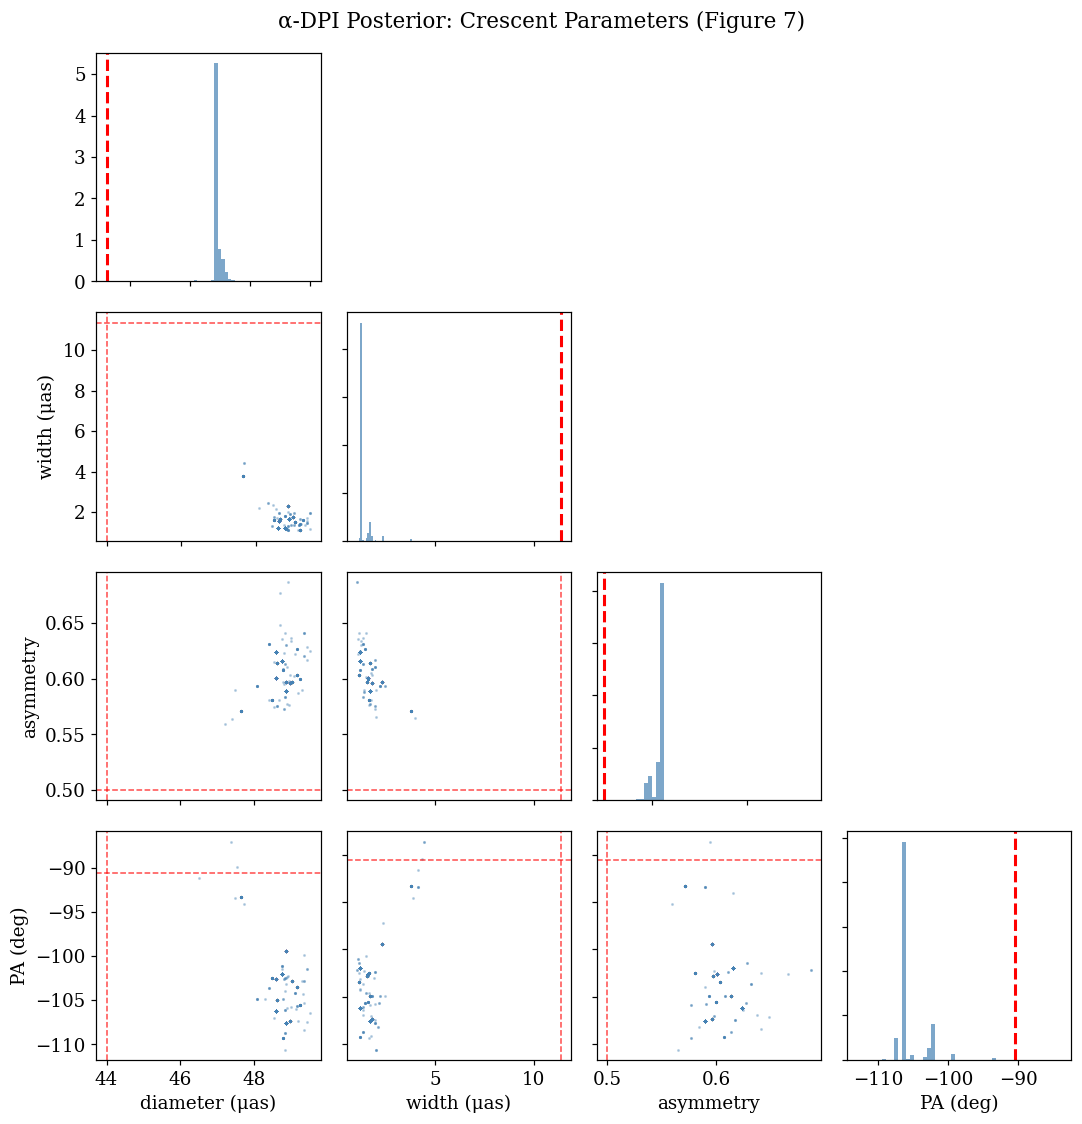

In [7]:
gt_array = np.array([
    gt_params_dict.get('diameter_uas', 44.0),
    gt_params_dict.get('width_uas', 11.36),
    gt_params_dict.get('asymmetry', 0.5),
    gt_params_dict.get('position_angle_deg', -90.5),
])
crescent_param_names = ['diameter (\u03bcas)', 'width (\u03bcas)', 'asymmetry', 'PA (deg)']

# Only plot the first 4 columns (crescent params) for readability
fig = plot_corner(
    params_physical[:, :4],
    param_names=crescent_param_names,
    ground_truth=gt_array,
    importance_weights=importance_weights,
)
fig.suptitle('\u03b1-DPI Posterior: Crescent Parameters (Figure 7)', y=1.02, fontsize=14)
plt.show()

In [8]:
# Print weighted posterior summary vs ground truth
w = importance_weights / importance_weights.sum()
print(f'{"Parameter":<20s} {"Ground Truth":>14s} {"Posterior Mean":>14s} {"Posterior Std":>14s}')
print('-' * 64)
for i, name in enumerate(crescent_param_names):
    gt_val = gt_array[i]
    post_mean = np.sum(w * params_physical[:, i])
    post_std = np.sqrt(np.sum(w * (params_physical[:, i] - post_mean)**2))
    print(f'{name:<20s} {gt_val:>14.2f} {post_mean:>14.2f} {post_std:>14.2f}')

Parameter              Ground Truth Posterior Mean  Posterior Std
----------------------------------------------------------------
diameter (μas)                44.00          48.64           0.15
width (μas)                   11.36           1.30           0.29
asymmetry                      0.50           0.62           0.01
PA (deg)                     -90.50        -105.44           2.05


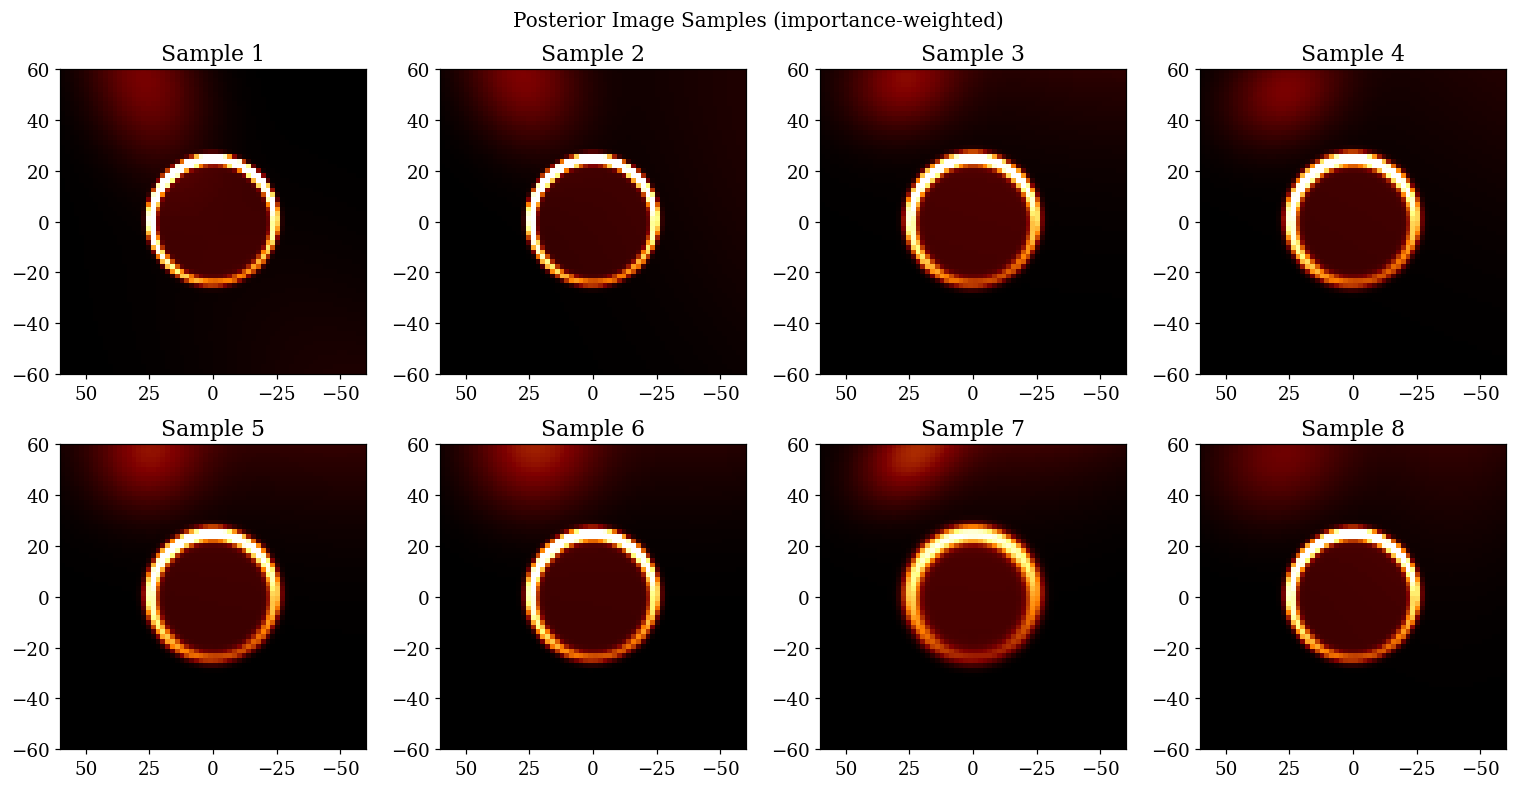

In [9]:
fig = plot_posterior_images(
    posterior_images, n_show=8,
    pixel_size_uas=pixel_size_uas,
    importance_weights=importance_weights,
)
fig.suptitle('Posterior Image Samples (importance-weighted)', y=1.02, fontsize=13)
plt.show()

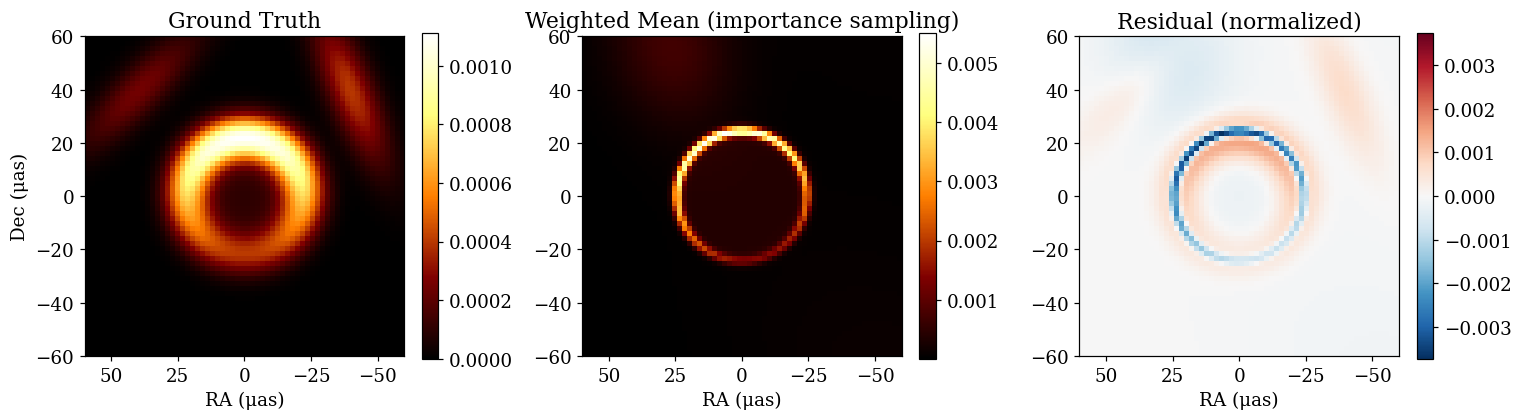

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

extent = [extent_uas, -extent_uas, -extent_uas, extent_uas]

im0 = axes[0].imshow(gt_image, origin='lower', cmap='afmhot', extent=extent)
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('RA (\u03bcas)')
axes[0].set_ylabel('Dec (\u03bcas)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(weighted_mean_image, origin='lower', cmap='afmhot', extent=extent)
axes[1].set_title('Weighted Mean (importance sampling)')
axes[1].set_xlabel('RA (\u03bcas)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

residual = gt_image / gt_image.sum() - weighted_mean_image / weighted_mean_image.sum()
vlim = np.abs(residual).max()
im2 = axes[2].imshow(residual, origin='lower', cmap='RdBu_r',
                      extent=extent, vmin=-vlim, vmax=vlim)
axes[2].set_title('Residual (normalized)')
axes[2].set_xlabel('RA (\u03bcas)')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [11]:
metrics = compute_feature_metrics(
    params_physical, gt_array,
    importance_weights=importance_weights,
    param_names=crescent_param_names,
)

print('Parameter Recovery Metrics (crescent parameters):')
print('=' * 56)
print_feature_metrics(metrics)

Parameter Recovery Metrics (crescent parameters):
  Parameter                  Bias        Std     1σ Cov
  ----------------------------------------------------
  diameter (μas)            4.643      0.150      0.000
  width (μas)             -10.060      0.295      0.000
  asymmetry                 0.118      0.011      0.000
  PA (deg)                -14.936      2.047      0.000


ELBO (n_gaussian=2): -85.3645

To perform full model selection, train separate models with
n_gaussian = 0, 1, 2, 3 and compare their ELBOs.
The model with highest ELBO is preferred (see Section 9).


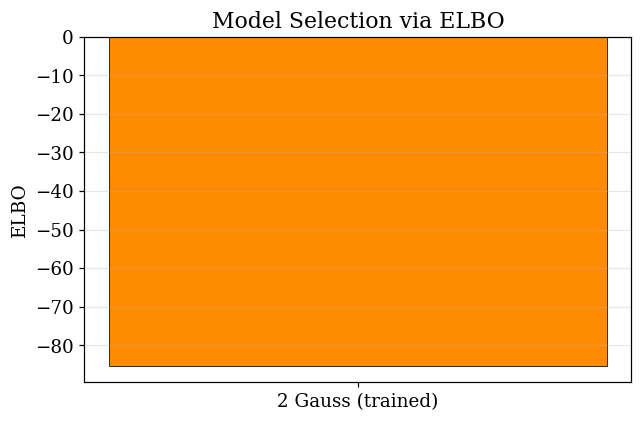

In [12]:
# Compute ELBO for the currently loaded model
elbo = solver.compute_elbo(
    obs_data, closure_indices, nufft_params, n_samples=10000
)
print(f'ELBO (n_gaussian={n_gaussian}): {elbo:.4f}')
print()
print('To perform full model selection, train separate models with')
print('n_gaussian = 0, 1, 2, 3 and compare their ELBOs.')
print('The model with highest ELBO is preferred (see Section 9).')

# Plot ELBO for the trained model
elbos = {f'{n_gaussian} Gauss (trained)': elbo}
fig = plot_elbo_comparison(elbos)
plt.show()

In [ ]:
# Uncomment to train from scratch (~30-60 min on GPU):
solver_train = AlphaDPISolver(
    npix=npix, fov_uas=fov_uas,
    n_flow=metadata['n_flow'],
    seqfrac=1.0 / metadata.get('seqfrac_inv', 16),
    n_epoch=metadata['n_epoch'],
    batch_size=metadata['batch_size'],
    lr=metadata['lr'],
    logdet_weight=metadata['logdet_weight'],
    grad_clip=metadata['grad_clip'],
    alpha=metadata.get('alpha_divergence', 1.0),
    beta=metadata.get('beta', 1.0),
    start_order=metadata.get('start_order', 4),
    decay_rate=metadata.get('decay_rate', 2000),
    geometric_model='simple_crescent_floor_nuisance',
    n_gaussian=n_gaussian,
    device=device,
)
result = solver_train.reconstruct(
    obs_data, closure_indices, nufft_params, flux_const)

plot_loss_curves(result['loss_history'])
plt.show()

  epoch     0/10000: loss=71.5518  cphase=286.4865  camp=409.8664  logdet=1.6118


In [13]:
metadata['n_flow']

16

In [14]:
metadata.get('seqfrac_inv', 16)

16

In [15]:
metadata['n_epoch']

10000

In [16]:
metadata['batch_size']

2048

In [17]:
metadata['lr']

0.0001

In [18]:
metadata['logdet_weight']

1.0

In [19]:
metadata['grad_clip']

0.0001

In [20]:
metadata.get('alpha_divergence', 1.0)

1.0

In [21]:
metadata.get('beta', 1.0)

1.0

In [22]:
metadata.get('decay_rate', 2000)

2000

In [32]:
# Uncomment to train from scratch (~30-60 min on GPU):
solver_train = AlphaDPISolver(
    npix=npix, fov_uas=fov_uas,
    n_flow=metadata['n_flow'],
    seqfrac=1.0 / metadata.get('seqfrac_inv', 16),
    n_epoch=10000,
    batch_size=metadata['batch_size'],
    lr=metadata['lr'],
    logdet_weight=metadata['logdet_weight'],
    grad_clip=metadata['grad_clip'],
    alpha=0.5,
    beta=0,
    start_order=metadata.get('start_order', 4),
    decay_rate=2000,
    geometric_model='simple_crescent_floor_nuisance',
    n_gaussian=n_gaussian,
    device=device,
)

In [33]:
result = solver_train.reconstruct(
    obs_data, closure_indices, nufft_params, flux_const)

  epoch     0/10000: loss=inf  cphase=283.2620  camp=410.0254  logdet=1.6129
  epoch  1000/10000: loss=inf  cphase=228.6638  camp=214.2726  logdet=1.4918


KeyboardInterrupt: 

In [30]:
solver_train.params_generator.parameters().device

AttributeError: 'generator' object has no attribute 'device'

In [31]:
next(solver_train.params_generator.parameters()).device


device(type='cuda', index=0)